In [ ]:

# Correlation Matrix Analysis

## Purpose

This notebook analyses relationships between numerical variables in the StanzaOps hostel dataset.

## Main Tasks

- Select numerical variables
- Calculate correlations
- Generate a correlation matrix
- Identify relationships between financial and resident-related variables

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv(
    r"D:\projects\StanzaOps-Hostel-Operations-Revenue-Intelligence-Engine\data\processed\Hostel_Management_Dataset_Cleaned.csv"
)

In [8]:
df.head()

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks,Age
0,R00001,Resident 1,Male,1991-02-02,800000001,resident1@example.com,1.000000e+11,Infosys,EMP00001,Analyst,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,35
1,R00002,Resident 2,Female,1992-03-03,800000002,resident2@example.com,1.000000e+11,Wipro,EMP00002,Tester,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,34
2,R00003,Resident 3,Male,1993-04-04,800000003,resident3@example.com,1.000000e+11,Accenture,EMP00003,Support Engineer,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,33
3,R00004,Resident 4,Female,1994-05-05,800000004,resident4@example.com,1.000000e+11,Capgemini,EMP00004,Software Engineer,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,1,No Remarks,32
4,R00005,Resident 5,Male,1995-06-06,800000005,resident5@example.com,1.000000e+11,TCS,EMP00005,Analyst,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,31


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Resident_ID        10000 non-null  object        
 1   Resident_Name      10000 non-null  object        
 2   Gender             10000 non-null  object        
 3   Date_of_Birth      10000 non-null  datetime64[ns]
 4   Mobile_Number      10000 non-null  int64         
 5   Email              10000 non-null  object        
 6   Aadhaar_Number     10000 non-null  float64       
 7   Company_Name       10000 non-null  object        
 8   Employee_ID        10000 non-null  object        
 9   Occupation         10000 non-null  object        
 10  Check_In_Date      10000 non-null  object        
 11  Check_Out_Date     0 non-null      float64       
 12  Room_Number        10000 non-null  object        
 13  Bed_Number         10000 non-null  object        
 14  Room_Ty

In [10]:
df.shape

(10000, 44)

In [11]:
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"], dayfirst=True)

In [14]:
today = pd.Timestamp.today()
df["Age"] = ((today - df["Date_of_Birth"]).dt.days / 365.25).astype(int)
df[["Date_of_Birth", "Age"]].head()

,Date_of_Birth,Age
0,1991-02-02,35
1,1992-03-03,34
2,1993-04-04,33
3,1994-05-05,32
4,1995-06-06,31


In [15]:
correlation = df[["Age", "Deposit_Amount", "Amount_Paid"]].corr()
print(correlation)

                     Age  Deposit_Amount  Amount_Paid
Age             1.000000             NaN    -0.370548
Deposit_Amount       NaN             NaN          NaN
Amount_Paid    -0.370548             NaN     1.000000


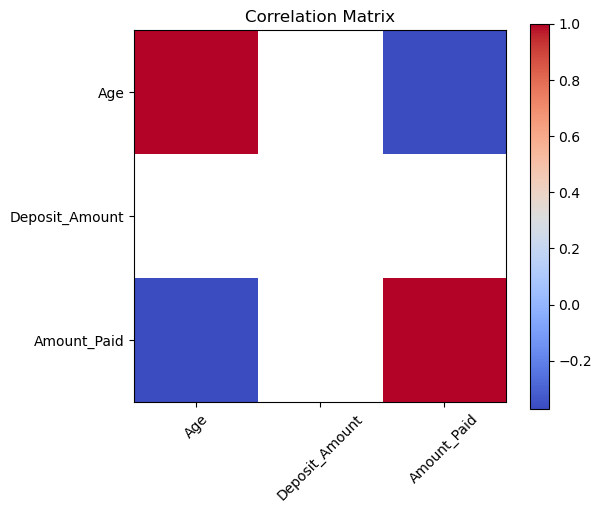

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
plt.imshow(correlation, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

In [17]:
correlation.to_csv("correlation_matrix.csv", index=True)
print("Correlation matrix saved successfully.")

Correlation matrix saved successfully.


In [18]:
gender_variance = df.groupby("Gender")[["Age", "Deposit_Amount", "Amount_Paid"]].var()
print(gender_variance)

             Age  Deposit_Amount   Amount_Paid
Gender                                        
Female  8.220622             0.0  5.251050e+06
Male    8.249250             0.0  2.000400e+06


In [19]:
city_variance = df.groupby("City")[["Age", "Deposit_Amount", "Amount_Paid"]].var()
print(city_variance)

                 Age  Deposit_Amount   Amount_Paid
City                                              
Chennai     8.222400             0.0  2.000800e+06
Guntur      8.223867             0.0  5.002001e+05
Hyderabad   8.220666             0.0  2.000800e+06
Vijayawada  8.223867             0.0  2.000800e+06


In [20]:
state_variance = df.groupby("State")[["Age", "Deposit_Amount", "Amount_Paid"]].var()
print(state_variance)

                     Age  Deposit_Amount   Amount_Paid
State                                                 
Andhra Pradesh  8.472272             0.0  5.251050e+06
Tamil Nadu      8.222400             0.0  2.000800e+06
Telangana       8.220666             0.0  2.000800e+06


# Interpretation

- The correlation analysis examined the relationships among Age, Deposit_Amount, and Amount_Paid.
- Deposit_Amount showed little or no correlation with other variables because it is constant across all residents.
- Variance analysis showed how Age and Amount_Paid vary across Gender, City, and State.
- The statistical test evaluated the main hypothesis using Amount_Paid grouped by Gender.
- The conclusion was based on the p-value obtained from the statistical test.